In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import logging
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, f1_score, roc_auc_score

from src.helper import *
from src.embedding import *
from src.model import *

In [2]:
#set config
EMBEDDED_DATA_PATH = "output/embeddings/wav2vec2/"
OUTPUT_PATH = "output/"
PREDS_PATH = "output/preds/"
MODELS_PATH = "models/"

#model training config
LEARNING_RATE = 0.01
EPOCHS = 30
WEIGHT_DECAY = 0

In [3]:
if not os.path.exists(OUTPUT_PATH):
    os.mkdir(OUTPUT_PATH)
if not os.path.exists(PREDS_PATH):
    os.mkdir(PREDS_PATH)
if not os.path.exists(MODELS_PATH):
    os.mkdir(MODELS_PATH)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# --- Setup logging ---
logging.basicConfig(
    filename=os.path.join(OUTPUT_PATH, f"nb_04_dl_models_log.log"),
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger("Main")
logger.info(f"starting DL modeling...")

### Preparing the data loader

In [6]:
logger.info(f"preparing the dataloader...")

train_loader, test_loader, holdout_loader = load_datasets(EMBEDDED_DATA_PATH, batch_size=64)

# Inspect one batch
for X, y, path in train_loader:
    logger.info(f"batch embeddings shape: {X.shape}")  # (batch_size, embedding_dim)
    logger.info(f"batch labels shape: {y.shape}")
    break

### Testing a simple 3 layer neural network

Key takeaways:
- Even a simple deep learning network with wav2vec2 embedding and 3 layers outperforms the best ML model with hand-crafted features.
- The SimpleAudioClassifier achieves a public score of 0.99642 compared to 0.98888 for the best ML model (catboost).

In [7]:
logger.info(f"starting SimpleAudioClassifier training...")
logger.info(f"learning rate: {LEARNING_RATE}, epoch: {EPOCHS}, weight decay: {WEIGHT_DECAY}")

X_batch, y_batch, path_batch = next(iter(train_loader))
input_dim = X_batch.shape[1]
num_classes = 2

model = SimpleAudioClassifier(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
# criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

model_name = f"simple_audio_classifier__cross_entropy__adam__lr_{str(LEARNING_RATE).replace('.', '_')}__epochs_{EPOCHS}__wd_{str(WEIGHT_DECAY).replace('.', '_')}"
model_save_path = os.path.join(MODELS_PATH, f"{model_name}.pth")

train_losses, train_f1s, val_losses, val_f1s = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    logger,
    model_save_path,
    epochs=EPOCHS
)

logger.info(f"SimpleAudioClassifier training finished")

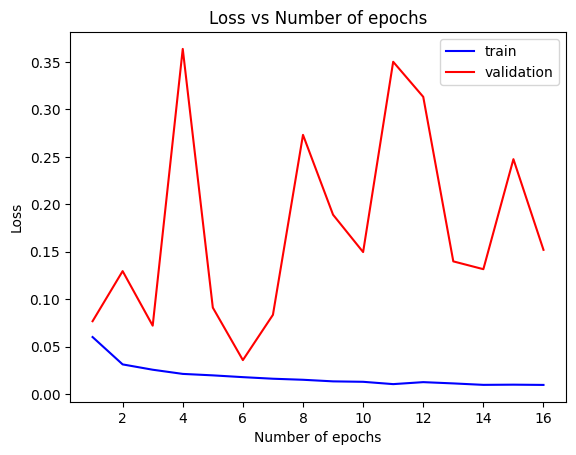

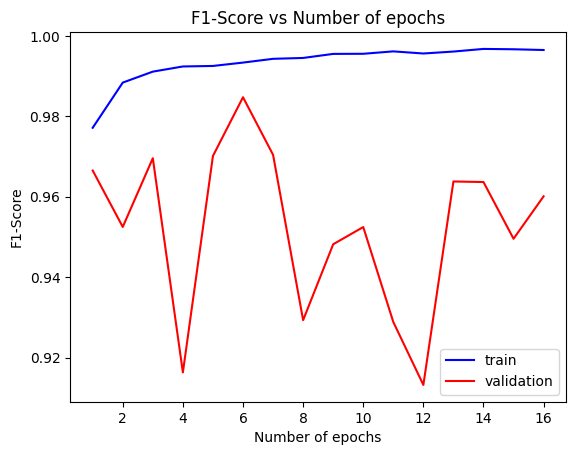

In [8]:
#plotting training results

plt.plot(range(1, len(train_losses)+1), train_losses, 'b')
plt.plot(range(1, len(val_losses)+1), val_losses, 'r')
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.title("Loss vs Number of epochs")
plt.legend(['train', 'validation'])
plt.show()

plt.plot(range(1, len(train_f1s)+1), train_f1s, 'b')
plt.plot(range(1, len(val_f1s)+1), val_f1s, 'r')
plt.xlabel("Number of epochs")
plt.ylabel("F1-Score")
plt.title("F1-Score vs Number of epochs")
plt.legend(['train', 'validation'])
plt.show()

In [9]:
logger.info(f"evaluating {model_name} best performing epoch...")
model.load_state_dict(torch.load(model_save_path))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch, path_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

#get score summary
logger.info(f"{model_name} test f1-score: {f1_score(y_true, y_pred)}")
logger.info(f"{model_name} classification report: \n{classification_report(y_true, y_pred, digits=5)}")

In [20]:
logger.info(f"generating {model_name} holdout prediction...")
model.eval()
y_holdout_id = []
y_holdout_pred = []
with torch.no_grad():
    for X_batch, y_batch, path_batch in holdout_loader:
        id = [p.split("/")[-1].split(".")[0]+".wav" for p in path_batch]
        y_holdout_id.extend(id)

        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_holdout_pred.extend(preds)

preds_save_path = os.path.join(PREDS_PATH, f'{model_name}_preds.csv')
df_holdout_preds = pd.DataFrame()
df_holdout_preds['id'] = y_holdout_id
df_holdout_preds['label'] = y_holdout_pred
df_holdout_preds.to_csv(preds_save_path, index=False)
logger.info(f"{model_name} holdout preds saved to {preds_save_path}")

In [7]:
logger.info(f"{model_name} result on kaggle leaderboard: 0.99642")